<a href="https://colab.research.google.com/github/domore9630-hue/PINNs-Physics-AI-Solutions/blob/main/Profile_Line.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

بدء تدريب نموذج الممر الحضري (Urban Canyon Multipath PINN)...

Epoch    1/1000 | Total Loss: 10.018912 | Physics Loss: 100.156662
Epoch  250/1000 | Total Loss: 0.004793 | Physics Loss: 0.047904
Epoch  500/1000 | Total Loss: 0.002097 | Physics Loss: 0.020963
Epoch  750/1000 | Total Loss: 0.000871 | Physics Loss: 0.008708
Epoch 1000/1000 | Total Loss: 0.000551 | Physics Loss: 0.005512

تم اكتمال تدريب نموذج الممر الحضري بنجاح!


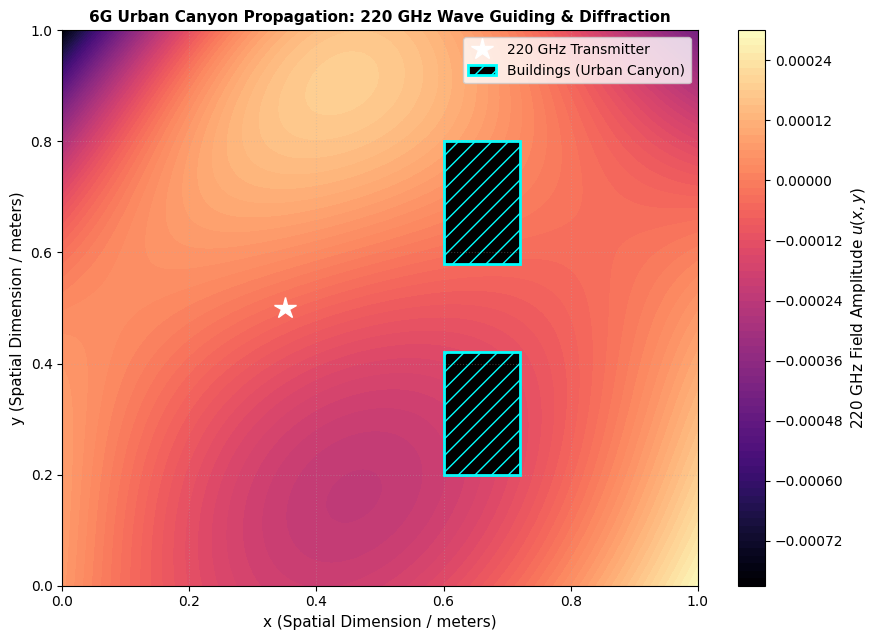

In [2]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. إعادة تعريف عمارة الشبكة العصبية للـ PINN الثنائي الأبعاد
class PINN2D(nn.Module):
    def __init__(self):
        super(PINN2D, self).__init__()
        # طبقات متصلة: مدخلان (x, y) -> طبقات مخفية -> مخرج واحد u(x,y)
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, y):
        # دمج الاحداثيات x و y كمدخلات للشبكة
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

# 2. إعداد المعلمات الفيزيائية للقناة
k_scaled = 15.0       # عدد الموجة
alpha_humidity = 0.5  # امتصاص جوي بسيط

# 3. تعريف العوائق المزدوجة (Urban Canyon: مبنيان مع ممر ضيق بينهما)
def urban_canyon_mask(x, y):
    b1 = (x >= 0.60) & (x <= 0.72) & (y >= 0.20) & (y <= 0.42)
    b2 = (x >= 0.60) & (x <= 0.72) & (y >= 0.58) & (y <= 0.80)
    return (b1 | b2).float()

# 4. مصدر الإشارة (عند اليسار قليلاً)
def antenna_source(x, y):
    sigma = 0.04
    return torch.exp(-((x - 0.35)**2 + (y - 0.5)**2) / (2 * sigma**2))

# 5. تجهيز نقاط الحدود والداخل (افتراض النقاط إذا لم تكن معرفة مسبقاً)
t = torch.linspace(0, 1, 50).view(-1, 1)
zeros = torch.zeros_like(t)
ones = torch.ones_like(t)
b_bottom = torch.cat([t, zeros], dim=1)
b_top    = torch.cat([t, ones], dim=1)
b_left   = torch.cat([zeros, t], dim=1)
b_right  = torch.cat([ones, t], dim=1)
b_points = torch.cat([b_bottom, b_top, b_left, b_right], dim=0).requires_grad_(True)

# نقاط الداخل للمجال الفيزيائي
x_val_phys = torch.linspace(0, 1, 40)
y_val_phys = torch.linspace(0, 1, 40)
gx, gy = torch.meshgrid(x_val_phys, y_val_phys, indexing='ij')
x_phys = gx.reshape(-1, 1).requires_grad_(True)
y_phys = gy.reshape(-1, 1).requires_grad_(True)

# 6. بناء نموذج الـ PINN الحضري والمحسن
model_canyon = PINN2D()
optimizer = torch.optim.Adam(model_canyon.parameters(), lr=0.003)

print("بدء تدريب نموذج الممر الحضري (Urban Canyon Multipath PINN)...\n")

# 7. حلقة التدريب (Training Loop)
epochs = 1000
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) الشروط الحدية للأطراف
    u_b = model_canyon(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) المشتقات المكانية عبر autograd
    u_phys = model_canyon(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # ج) خمود العوائق الحضرية
    canyon_mask = urban_canyon_mask(x_phys, y_phys)
    sigma_canyon = 120.0 * canyon_mask

    # د) متبقي معادلة هلمهولتز للممر الحضري
    f_source = antenna_source(x_phys, y_phys)
    helmholtz_residual = (
        (d2u_dx2 + d2u_dy2)
        + (k_scaled ** 2) * u_phys
        - (alpha_humidity + sigma_canyon) * u_phys
        + f_source
    )
    loss_physics = torch.mean(helmholtz_residual ** 2)

    # هـ) خسارة منع نفاذ الموجة داخل المباني
    loss_blockage = torch.mean((u_phys * canyon_mask) ** 2)

    # الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics + 15.0 * loss_blockage
    total_loss.backward()
    optimizer.step()

    if epoch % 250 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم اكتمال تدريب نموذج الممر الحضري بنجاح!")

# 8. رسم الخريطة الحرارية للممر الحضري
eval_size = 100
x_val_eval = torch.linspace(0, 1, eval_size)
y_val_eval = torch.linspace(0, 1, eval_size)
grid_x_eval, grid_y_eval = torch.meshgrid(x_val_eval, y_val_eval, indexing='ij')
x_eval_flat = grid_x_eval.reshape(-1, 1)
y_eval_flat = grid_y_eval.reshape(-1, 1)

with torch.no_grad():
    u_canyon_flat = model_canyon(x_eval_flat, y_eval_flat)
u_canyon_2d = u_canyon_flat.reshape(eval_size, eval_size).numpy()

plt.figure(figsize=(9, 6.5))
contour = plt.contourf(grid_x_eval.numpy(), grid_y_eval.numpy(), u_canyon_2d, levels=80, cmap='magma')
cbar = plt.colorbar(contour)
cbar.set_label('220 GHz Field Amplitude $u(x,y)$', fontsize=11)

plt.plot(0.35, 0.5, 'w*', markersize=16, label='220 GHz Transmitter')

rect1 = patches.Rectangle((0.60, 0.20), 0.12, 0.22, linewidth=2, edgecolor='cyan', facecolor='black', hatch='//', label='Buildings (Urban Canyon)')
rect2 = patches.Rectangle((0.60, 0.58), 0.12, 0.22, linewidth=2, edgecolor='cyan', facecolor='black', hatch='//')
plt.gca().add_patch(rect1)
plt.gca().add_patch(rect2)

plt.title('6G Urban Canyon Propagation: 220 GHz Wave Guiding & Diffraction', fontsize=11, fontweight='bold')
plt.xlabel('x (Spatial Dimension / meters)', fontsize=11)
plt.ylabel('y (Spatial Dimension / meters)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

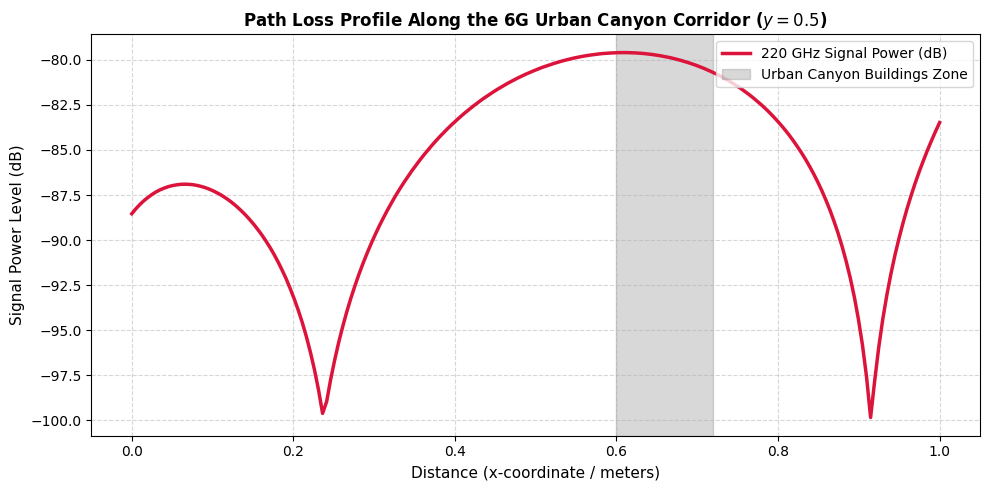

In [4]:

# 1. تحديد خط سير أفقياً يمر عبر منتصف الممر الحضري (عند y = 0.5)
x_path = torch.linspace(0, 1, 200).view(-1, 1)
y_path = torch.full_like(x_path, 0.5)  # يمر بالمنتصف حيث الممر بين المبنيين

# 2. حساب قيمة سعة المجال عبر هذا المسار باستخدام النموذج المدرب
with torch.no_grad():
    u_path_pred = model_canyon(x_path, y_path)

# تحويل البيانات إلى NumPy للرسم
x_np = x_path.numpy().flatten()
u_np = u_path_pred.numpy().flatten()

# حساب القدرة بالديسيبل (Path Loss / Power in dB) لتسهيل التحليل الهندسي
# Power dB = 20 * log10(|u| + 1e-5)
power_db = 20 * np.log10(np.abs(u_np) + 1e-5)

# 3. رسم منحنى تضاؤل القدرة (Path Loss Profile)
plt.figure(figsize=(10, 5))
plt.plot(x_np, power_db, color='crimson', linewidth=2.5, label='220 GHz Signal Power (dB)')

# تظليل منطقة وجود المباني لتوضيح أثر التظليل (Shadowing Region)
plt.axvspan(0.60, 0.72, color='gray', alpha=0.3, label='Urban Canyon Buildings Zone')

plt.title('Path Loss Profile Along the 6G Urban Canyon Corridor ($y = 0.5$)', fontsize=12, fontweight='bold')
plt.xlabel('Distance (x-coordinate / meters)', fontsize=11)
plt.ylabel('Signal Power Level (dB)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()